In [1]:
from numpy import random, array

#Create fake income/age clusters for N people in k clusters
def createClusteredData(N, k):
    random.seed(10)
    pointsPerCluster = float(N)/k
    X = []
    for i in range (k):
        incomeCentroid = random.uniform(20000.0, 200000.0)
        ageCentroid = random.uniform(20.0, 70.0)
        for j in range(int(pointsPerCluster)):
            X.append([random.normal(incomeCentroid, 10000.0), random.normal(ageCentroid, 2.0)])
    X = array(X)
    return X

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


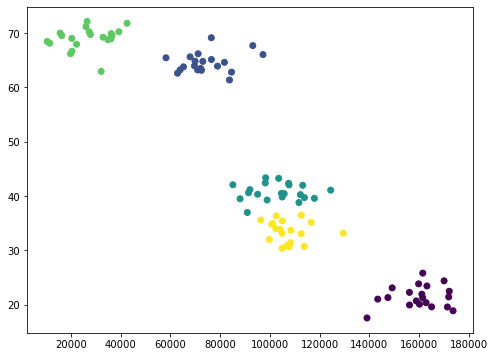

In [2]:
%matplotlib inline

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale
from numpy import random, float

data = createClusteredData(100, 5)

model = KMeans(n_clusters=5)

# Note I'm scaling the data to normalize it! Important for good results.
model = model.fit(scale(data))

# We can look at the clusters each data point was assigned to
print(model.labels_)

# And we'll visualize it:
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model.labels_.astype(float))
plt.show()

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 4 4 4 4 4 4 1 1 4 4 1 4 1 4 4 4 4
 4 4 1 3 3 3 3 3 3 1 3 3 1 3 3 3 3 3 3 3 3 1 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 3 1 3 1 3 3 1 3 3 3 1 3 1 1 3 3 3 1 1]


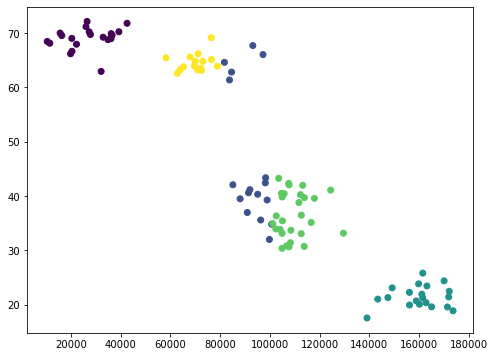

In [5]:
# what happens if you don't scale the data? What happens if you choose different values of K?

model_not_scaled = model.fit(data)
print(model_not_scaled.labels_)
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_not_scaled.labels_.astype(float))
plt.show()

# Not scaling the data significantly reduces de model performance. This is a well known result in K-means clustering.

In [8]:
# Let's try several different values for k. 

model_2 = KMeans(n_clusters=2)
model_3 = KMeans(n_clusters=3)
model_4 = KMeans(n_clusters=4)
model_6 = KMeans(n_clusters=6)
model_7 = KMeans(n_clusters=7)

model_2 = model_2.fit(scale(data))
model_3 = model_3.fit(scale(data))
model_4 = model_4.fit(scale(data))
model_6 = model_6.fit(scale(data))
model_7 = model_7.fit(scale(data))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


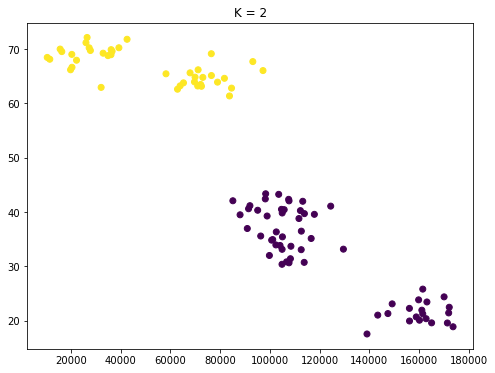

In [9]:
print(model_2.labels_)
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_2.labels_.astype(float))
plt.title("K = 2")
plt.show()

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


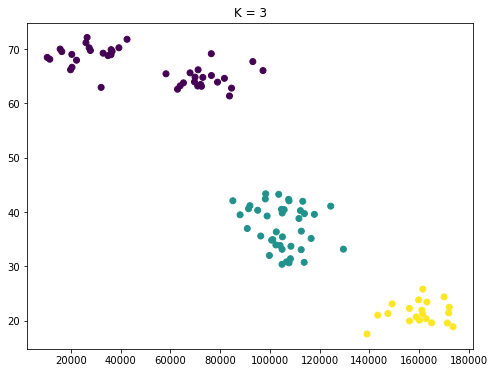

In [10]:
print(model_3.labels_)
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_3.labels_.astype(float))
plt.title("K = 3")
plt.show()

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


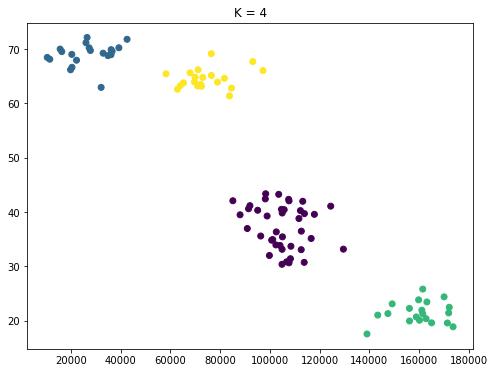

In [11]:
print(model_4.labels_)
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_4.labels_.astype(float))
plt.title("K = 4")
plt.show()

# This looks like the best option

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 5 2 5 2 5 2 2 5 2 2 2 5 2 5 5 2 2 2 5 5]


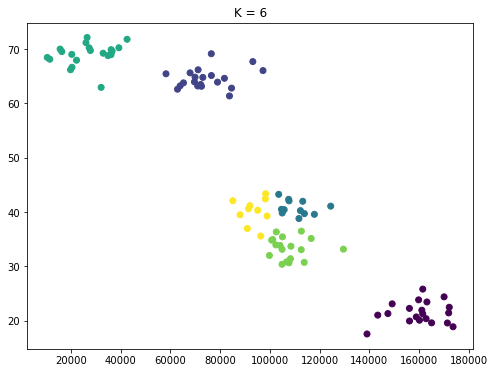

In [12]:
print(model_6.labels_)
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_6.labels_.astype(float))
plt.title("K = 6")
plt.show()

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 5 5 5 5 5 5 5 5 5 2 5 5 5 5 5 5 5 5 5 4 1 1 1 6 6 6 1 1 6 6 1 6 1 1
 1 6 6 1 1 1 2 4 2 4 2 4 4 2 4 4 4 2 4 2 2 4 4 4 2 2]


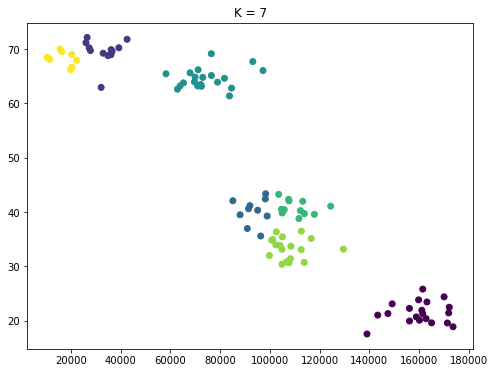

In [13]:
print(model_7.labels_)
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_7.labels_.astype(float))
plt.title("K = 7")
plt.show()

In [16]:
# N = 100
model_n = KMeans(n_clusters=100)
model_1 = KMeans(n_clusters=1)

model_n = model_n.fit(scale(data))
model_1 = model_1.fit(scale(data))

C:\Users\Fede\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[15 10 72  2 82 60 35 84 54 11 29 49 46 22 40 38 58 75 44 68 86 21 78 66
 18  6  3 42 37 87 65 96 30 69 62 63 26 41 59 13 76 67 95 51 71 32 56 43
  9 31 85  0 20 50 12 25 99 80 47  7 97 61 57 45 36 89  1 34 93  5 79 16
 17 52 74 70 88 14 92 90 39 23 33 48 64 98 83 55  4 27 94 19 77  8 81 73
 28 53 91 24]


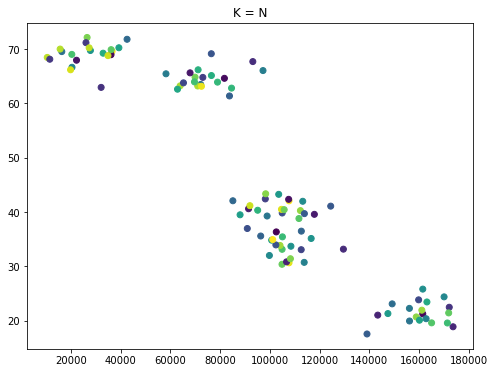

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_n.labels_.astype(float))
plt.title("K = N")
plt.show()

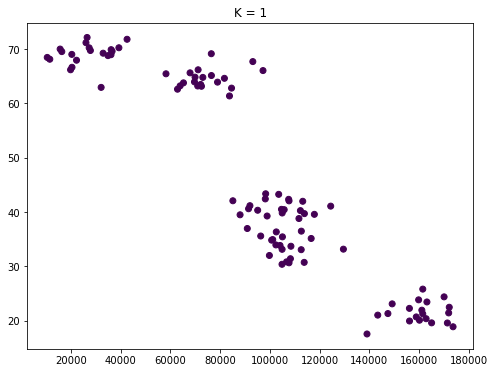

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(data[:,0], data[:,1], c=model_1.labels_.astype(float))
plt.title("K = 1")
plt.show()